In [ ]:
import os
os.environ["GROQ_API_KEY"] = "groq api key"

In [2]:
!pip install numpy==1.26.4

In [3]:
!pip uninstall -y bitsandbytes triton peft trl transformers accelerate
!pip install -q transformers==4.40.0
!pip install -q datasets==2.18.0
!pip install -q peft==0.10.0
!pip install -q trl==0.8.6
!pip install -q accelerate==0.29.3
!pip install -q bitsandbytes==0.41.3
!pip install -q groq
!pip install -q torch==2.2.2
print("done.")

Found existing installation: bitsandbytes 0.41.3
Uninstalling bitsandbytes-0.41.3:
  Successfully uninstalled bitsandbytes-0.41.3
Found existing installation: peft 0.10.0
Uninstalling peft-0.10.0:
  Successfully uninstalled peft-0.10.0
Found existing installation: trl 0.8.6
Uninstalling trl-0.8.6:
  Successfully uninstalled trl-0.8.6
Found existing installation: transformers 4.40.0
Uninstalling transformers-4.40.0:
  Successfully uninstalled transformers-4.40.0
Found existing installation: accelerate 0.29.3
Uninstalling accelerate-0.29.3:
  Successfully uninstalled accelerate-0.29.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
done.


In [4]:
!pip install -q groq
!pip install -q transformers==4.40.0
!pip install -q datasets==2.18.0
!pip install -q peft==0.10.0
!pip install -q trl==0.8.6
!pip install -q accelerate==0.29.3
!pip install -q bitsandbytes==0.43.1
!pip install -q torch==2.2.2
print("All dependencies installed.")

All dependencies installed.


In [ ]:
import os

os.environ["GEMINI_API_KEY"] = "Gem api key"

GEMINI_API_KEY = os.environ["GEMINI_API_KEY"]

gemini_client = OpenAI(
    api_key=GEMINI_API_KEY,
    base_url="https://generativelanguage.googleapis.com/v1beta/openai"
)

In [7]:
import os, gc, json, time, re, random, torch, warnings
warnings.filterwarnings("ignore")
from dataclasses import dataclass, field
from typing import Optional
from groq import Groq
from openai import OpenAI

GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "")
if not GROQ_API_KEY:
    raise RuntimeError("GROQ_API_KEY not set.")

GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY", "")
if not GEMINI_API_KEY:
    raise RuntimeError("GEMINI_API_KEY not set.")

client = Groq(api_key=GROQ_API_KEY)
GROQ_MODEL = "llama-3.1-8b-instant"

gemini_client = OpenAI(
    api_key  = GEMINI_API_KEY,
    base_url = "https://generativelanguage.googleapis.com/v1beta/openai"
)
GEMINI_MODEL = "gemini-2.5-flash"

BASE_MODEL   = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
FT_DIR       = "./ft_extractor"
TRAIN_FILE   = "./train.json"
VAL_FILE     = "./val.json"
DATA_PATH    = "./project_omni_pclub_secy_recruit_dataset.json"
DATASET_PATH = "./project_omni_pclub_secy_recruit_dataset.json"
REPORTS_DIR  = "./reports"

ALLOWED_RELS = {"at", "with", "motive", "owns", "knows", "did"}

MOTIVE_WORDS = {
    "motive", "conflict", "argument", "hate", "dispute",
    "rival",  "bitter",  "disagree", "jealous", "envy",
    "anger",  "resent",  "betray",   "revenge", "grudge",
}

PTS_TIMELINE_LIE     = 25
PTS_WITNESS_CONFLICT = 20
PTS_SCENE_PRESENCE   = 15
PTS_MOTIVE           = 15
PTS_NO_ALIBI         = 10
PTS_ALIBI_CLEAR      = -15

MAX_ROUNDS = 3
GAP_RATIO  = 1.5

token_log = {"prompt": 0, "completion": 0, "total": 0}

os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs("outputs",   exist_ok=True)
os.makedirs("logs",      exist_ok=True)


def ask_groq(msgs: list, max_tok: int = 300) -> str:
    global token_log
    for attempt in range(3):
        try:
            time.sleep(1.5)
            r = client.chat.completions.create(
                model=GROQ_MODEL, messages=msgs,
                max_tokens=max_tok, temperature=0.2,
            )
            if not r or not getattr(r, "choices", None):
                return ""
            u = getattr(r, "usage", None)
            if u:
                token_log["prompt"]     += getattr(u, "prompt_tokens",     0)
                token_log["completion"] += getattr(u, "completion_tokens", 0)
                token_log["total"]      += getattr(u, "total_tokens",      0)
            return r.choices[0].message.content.strip()
        except Exception as e:
            err = str(e)
            if "401" in err:
                raise RuntimeError("Bad Groq API key.")
            if "429" in err:
                w = 15 * (attempt + 1)
                print(f"[Groq] rate limit, waiting {w}s...")
                time.sleep(w)
            else:
                print(f"[Groq] {err}")
                if attempt == 2:
                    return ""
    return ""


def clean(text) -> str:
    if isinstance(text, list):
        return " ".join(str(t) for t in text).strip()
    return str(text).strip() if text else ""


print(f"GPU: {torch.cuda.is_available()}")
print("config done.")

GPU: True
config done.


In [8]:
@dataclass
class Claim:
    who       : str
    rel       : str
    what      : str
    when      : Optional[str]
    said_by   : str
    conf      : float
    original  : str

    def ok(self) -> bool:
        return bool(
            self.who.strip() and
            self.rel in ALLOWED_RELS and
            self.what.strip()
        )


@dataclass
class Clash:
    c1          : Claim
    c2          : Claim
    clash_type  : str
    why         : str
    strength    : float = 1.0


@dataclass
class Person:
    name          : str
    claims        : list = field(default_factory=list)
    clashes       : list = field(default_factory=list)
    suspicion     : float = 0.0
    alibi_solid   : bool  = False
    has_motive    : bool  = False
    q_count       : int   = 0


@dataclass
class TimeNode:
    suspect  : str
    time_str : str
    location : str
    source   : str
    time_mins: int = 0


print("classes done.")

classes done.


In [9]:
def parse_time(t: str) -> int:
    t = t.strip().upper()
    try:
        is_pm = "PM" in t
        is_am = "AM" in t
        t = t.replace("AM", "").replace("PM", "").strip()
        if ":" in t:
            h, m = t.split(":")
        else:
            h, m = t, "0"
        h, m = int(h.strip()), int(m.strip())
        if is_pm and h != 12:
            h += 12
        if is_am and h == 12:
            h = 0
        return h * 60 + m
    except:
        return -1


def extract_location(activity: str) -> Optional[str]:
    activity = activity.lower()
    patterns = [
        r"(?:at|in|to|arrives at|reaches|heads to)\s+(the\s+[\w\s]{3,35})",
        r"(?:at|in|to)\s+([\w\s]{3,25}(?:library|room|office|home|hotel|cafe|garden|hall|mansion|university|department))",
        r"(?:returns to|goes to|visits)\s+([\w\s]{3,30})",
    ]
    for pat in patterns:
        m = re.search(pat, activity)
        if m:
            loc = m.group(1).strip()
            if len(loc) > 3:
                return loc[:60]
    generic_locs = ["home", "office", "library", "university", "apartment", "cafe", "hotel"]
    for loc in generic_locs:
        if loc in activity:
            return loc
    return None


class TimelineGraph:
    def __init__(self):
        self.nodes : list[TimeNode] = []

    def load_suspect(self, name: str, profile: dict):
        raw_timeline = profile.get("timeline", {})
        if isinstance(raw_timeline, dict):
            raw_timeline = raw_timeline.get("timeline", [])
        if not isinstance(raw_timeline, list):
            return
        for entry in raw_timeline:
            t_str    = entry.get("time",     "")
            activity = entry.get("activity", "")
            location = extract_location(activity)
            if not location or not t_str:
                continue
            t_mins = parse_time(t_str)
            if t_mins < 0:
                continue
            self.nodes.append(TimeNode(
                suspect  = name,
                time_str = t_str,
                location = location,
                source   = "timeline",
                time_mins= t_mins,
            ))

    def get_location_at(self, suspect: str, time_mins: int,
                         window: int = 45) -> Optional[str]:
        candidates = [
            n for n in self.nodes
            if n.suspect == suspect and
               abs(n.time_mins - time_mins) <= window
        ]
        if not candidates:
            return None
        closest = min(candidates, key=lambda n: abs(n.time_mins - time_mins))
        return closest.location

    def rule1_self_lie(self, suspect: str,
                        claimed_loc: str,
                        claimed_time_mins: int) -> Optional[str]:
        actual = self.get_location_at(suspect, claimed_time_mins)
        if not actual:
            return None
        if actual.lower() not in claimed_loc.lower() and \
           claimed_loc.lower() not in actual.lower():
            return (
                f"{suspect} claims to be at '{claimed_loc}' "
                f"but their timeline places them at '{actual}' "
                f"at the same time."
            )
        return None

    def rule2_witness_conflict(self, suspect: str,
                                witness: str,
                                witness_says_loc: str,
                                time_mins: int) -> Optional[str]:
        actual = self.get_location_at(suspect, time_mins)
        if not actual:
            return None
        if actual.lower() not in witness_says_loc.lower() and \
           witness_says_loc.lower() not in actual.lower():
            return (
                f"{witness} claims to have seen {suspect} at "
                f"'{witness_says_loc}', but {suspect}'s timeline "
                f"places them at '{actual}' at that time."
            )
        return None

    def rule3_scene_presence(self, suspect: str,
                              crime_location: str,
                              crime_time_mins: int,
                              window: int = 60) -> bool:
        loc = self.get_location_at(suspect, crime_time_mins, window)
        if not loc:
            return False
        return (
            crime_location.lower() in loc.lower() or
            loc.lower() in crime_location.lower()
        )

    def run_all_checks(self, suspects: list[dict],
                        crime_location: str,
                        crime_time_str: str) -> list[tuple]:
        flags   = []
        c_time  = parse_time(crime_time_str) if crime_time_str else -1

        for s in suspects:
            name = s["name"]

            if c_time > 0:
                at_scene = self.rule3_scene_presence(
                    name, crime_location, c_time)
                if at_scene:
                    flags.append((name, "scene_presence",
                        f"{name}'s timeline places them at or near "
                        f"the crime scene around the time of the murder.",
                        PTS_SCENE_PRESENCE))

            testimony = clean(s.get("testimony", ""))
            if testimony:
                loc_match = re.search(
                    r"(?:saw|noticed|spotted)\s+([\w\s]+)\s+"
                    r"(?:at|near|in)\s+(the\s+[\w\s]{3,30}|[\w\s]{3,20}"
                    r"(?:section|room|wing|area|hall))",
                    testimony, re.IGNORECASE
                )
                if loc_match:
                    seen_person = loc_match.group(1).strip()
                    seen_loc    = loc_match.group(2).strip()
                    conflict    = self.rule2_witness_conflict(
                        seen_person, name, seen_loc, c_time)
                    if conflict:
                        flags.append((seen_person, "witness_conflict",
                            conflict, PTS_WITNESS_CONFLICT))

        return flags


print("TimelineGraph ready.")

TimelineGraph ready.


In [10]:
def get_location_from_text(text: str) -> Optional[str]:
    pats = [
        r"I was (?:at|in) (the [\w\s]{3,40})",
        r"I was (?:at|in) ([\w\s]{3,30}"
        r"(?:library|room|office|home|hotel|garden|hall))",
        r"(?:at|in) (my [\w\s]{3,20})",
    ]
    for p in pats:
        m = re.search(p, text, re.IGNORECASE)
        if m:
            return m.group(1).strip()[:80]
    return None


def build_pairs(dataset: list) -> list:
    pairs = []
    for case in dataset:
        victim = case.get("victim", {}).get("name", "the victim")
        for s in case.get("suspects", []):
            name    = s.get("name", "")
            testy   = clean(s.get("testimony",    ""))
            motive  = clean(s.get("motive",       ""))
            opp     = clean(s.get("opportunity",  ""))
            rel     = clean(s.get("relationship", ""))
            if not testy or not name:
                continue
            facts = []
            if rel:
                facts.append({
                    "who": name, "rel": "knows",
                    "what": victim, "when": None, "conf": 1.0,
                })
            if motive:
                facts.append({
                    "who": name, "rel": "motive",
                    "what": motive[:120], "when": None, "conf": 1.0,
                })
            if opp:
                facts.append({
                    "who": name, "rel": "did",
                    "what": opp[:120], "when": None, "conf": 1.0,
                })
            loc = get_location_from_text(testy)
            if loc:
                facts.append({
                    "who": name, "rel": "at",
                    "what": loc, "when": None, "conf": 1.0,
                })
            if not facts:
                continue
            inp = (
                f"Extract structured facts from this murder "
                f"investigation testimony.\n"
                f"Speaker: {name}\n"
                f"Testimony: {testy[:400]}\n\n"
                f"Return a JSON array. Each item must have: "
                f"who, rel, what, when (or null), conf (0.0-1.0).\n"
                f"rel must be one of: at, with, motive, owns, knows, did.\n"
                f"Return ONLY the JSON array."
            )
            pairs.append({"input": inp, "output": json.dumps(facts)})
    return pairs


with open(DATA_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)
print(f"loaded {len(dataset)} cases.")

all_pairs = build_pairs(dataset)
random.seed(42)
random.shuffle(all_pairs)

cut         = int(0.8 * len(all_pairs))
train_pairs = all_pairs[:cut]
val_pairs   = all_pairs[cut:]

with open(TRAIN_FILE, "w") as f: json.dump(train_pairs, f, indent=2)
with open(VAL_FILE,   "w") as f: json.dump(val_pairs,   f, indent=2)

print(f"train: {len(train_pairs)} | val: {len(val_pairs)}")
print("\nsample input:\n",  train_pairs[0]["input"][:300])
print("\nsample output:\n", train_pairs[0]["output"])

loaded 401 cases.
train: 1283 | val: 321

sample input:
 Extract structured facts from this murder investigation testimony.
Speaker: Ms. Isabella Green
Testimony: Ms. Green saw Mr. Hastings outside the library on a phone call during the time of the murder.

Return a JSON array. Each item must have: who, rel, what, when (or null), conf (0.0-1.0).
rel must 

sample output:
 [{"who": "Ms. Isabella Green", "rel": "knows", "what": "Jonathan Blackwood", "when": null, "conf": 1.0}, {"who": "Ms. Isabella Green", "rel": "motive", "what": "Ms. Green had no apparent motive to harm Jonathan Blackwood, as their relationship was cordial and mutually beneficial.", "when": null, "conf": 1.0}, {"who": "Ms. Isabella Green", "rel": "did", "what": "Ms. Green was present in the library during the time of the murder, as she was examining the artifacts on display. While", "when": null, "conf": 1.0}]


In [11]:
!pip uninstall -y bitsandbytes
!pip install -q bitsandbytes==0.41.3

Found existing installation: bitsandbytes 0.43.1
Uninstalling bitsandbytes-0.43.1:
  Successfully uninstalled bitsandbytes-0.43.1


In [12]:
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    TrainingArguments, BitsAndBytesConfig,
)
from peft    import LoraConfig, get_peft_model, TaskType
from trl     import SFTTrainer
from datasets import Dataset as HFData

with open(TRAIN_FILE) as f: tr = json.load(f)
with open(VAL_FILE)   as f: vl = json.load(f)


def fmt(p: dict) -> str:
    return (
        "<|system|>You extract structured facts from murder investigation "
        "testimonies. Output only valid JSON.</s>\n"
        f"<|user|>{p['input']}</s>\n"
        f"<|assistant|>{p['output']}</s>"
    )


tr_hf = HFData.from_dict({"text": [fmt(p) for p in tr]})
vl_hf = HFData.from_dict({"text": [fmt(p) for p in vl]})
print(f"train: {len(tr_hf)} | val: {len(vl_hf)}")

bnb = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("loading TinyLlama...")
tok = AutoTokenizer.from_pretrained(BASE_MODEL)
tok.pad_token = tok.eos_token

mdl = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, quantization_config=bnb, device_map="auto")
mdl.config.use_cache = False

lora = LoraConfig(
    task_type=TaskType.CAUSAL_LM, r=16, lora_alpha=32,
    lora_dropout=0.05, target_modules=["q_proj", "v_proj"], bias="none",
)
mdl = get_peft_model(mdl, lora)
mdl.print_trainable_parameters()

args = TrainingArguments(
    output_dir=FT_DIR, num_train_epochs=3,
    per_device_train_batch_size=4, per_device_eval_batch_size=4,
    gradient_accumulation_steps=2, learning_rate=2e-4,
    fp16=True, logging_steps=25, evaluation_strategy="epoch",
    save_strategy="epoch", load_best_model_at_end=True,
    warmup_ratio=0.05, lr_scheduler_type="cosine", report_to="none",
)

trainer = SFTTrainer(
    model=mdl, args=args, train_dataset=tr_hf, eval_dataset=vl_hf,
    dataset_text_field="text", max_seq_length=512, tokenizer=tok,
)

print("fine-tuning ")
trainer.train()
trainer.save_model(FT_DIR)
tok.save_pretrained(FT_DIR)
print(f"saved to {FT_DIR}.")

del mdl, trainer
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

train: 1283 | val: 321
loading TinyLlama...
trainable params: 2,252,800 || all params: 1,102,301,184 || trainable%: 0.20437245579516677


Map:   0%|          | 0/1283 [00:00<?, ? examples/s]

Map:   0%|          | 0/321 [00:00<?, ? examples/s]

fine-tuning 


Epoch,Training Loss,Validation Loss
0,0.401700,0.384711
2,0.335900,0.345774


saved to ./ft_extractor.


In [13]:
def get_location_from_text(text: str) -> Optional[str]:
    pats = [
        r"I was (?:at|in) (the [\w\s]{3,40})",
        r"I was (?:at|in) ([\w\s]{3,30}(?:library|room|office|home|hotel|garden|hall))",
        r"(?:at|in) (my [\w\s]{3,20})",
    ]
    for p in pats:
        m = re.search(p, text, re.IGNORECASE)
        if m:
            return m.group(1).strip()[:80]
    return None


def build_pairs(dataset: list) -> list:
    pairs = []
    for case in dataset:
        victim = case.get("victim", {}).get("name", "the victim")
        for s in case.get("suspects", []):
            name    = s.get("name", "")
            testy   = clean(s.get("testimony",    ""))
            motive  = clean(s.get("motive",       ""))
            opp     = clean(s.get("opportunity",  ""))
            rel     = clean(s.get("relationship", ""))
            if not testy or not name:
                continue
            facts = []
            if rel:
                facts.append({
                    "who": name, "rel": "knows",
                    "what": victim, "when": None, "conf": 1.0,
                })
            if motive:
                facts.append({
                    "who": name, "rel": "motive",
                    "what": motive[:120], "when": None, "conf": 1.0,
                })
            if opp:
                facts.append({
                    "who": name, "rel": "did",
                    "what": opp[:120], "when": None, "conf": 1.0,
                })
            loc = get_location_from_text(testy)
            if loc:
                facts.append({
                    "who": name, "rel": "at",
                    "what": loc, "when": None, "conf": 1.0,
                })
            if not facts:
                continue
            inp = (
                f"Extract structured facts from this murder "
                f"investigation testimony.\n"
                f"Speaker: {name}\n"
                f"Testimony: {testy[:400]}\n\n"
                f"Return a JSON array. Each item must have: "
                f"who, rel, what, when (or null), conf (0.0-1.0).\n"
                f"rel must be one of: at, with, motive, owns, knows, did.\n"
                f"Return ONLY the JSON array."
            )
            pairs.append({"input": inp, "output": json.dumps(facts)})
    return pairs


with open(DATASET_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)
print(f"loaded {len(dataset)} cases.")

all_pairs = build_pairs(dataset)
random.seed(42)
random.shuffle(all_pairs)

cut         = int(0.8 * len(all_pairs))
train_pairs = all_pairs[:cut]
val_pairs   = all_pairs[cut:]

with open(TRAIN_FILE, "w") as f: json.dump(train_pairs, f, indent=2)
with open(VAL_FILE,   "w") as f: json.dump(val_pairs,   f, indent=2)

print(f"train: {len(train_pairs)} | val: {len(val_pairs)}")
print("\nsample input:\n",  train_pairs[0]["input"][:300])
print("\nsample output:\n", train_pairs[0]["output"])

loaded 401 cases.
train: 1283 | val: 321

sample input:
 Extract structured facts from this murder investigation testimony.
Speaker: Ms. Isabella Green
Testimony: Ms. Green saw Mr. Hastings outside the library on a phone call during the time of the murder.

Return a JSON array. Each item must have: who, rel, what, when (or null), conf (0.0-1.0).
rel must 

sample output:
 [{"who": "Ms. Isabella Green", "rel": "knows", "what": "Jonathan Blackwood", "when": null, "conf": 1.0}, {"who": "Ms. Isabella Green", "rel": "motive", "what": "Ms. Green had no apparent motive to harm Jonathan Blackwood, as their relationship was cordial and mutually beneficial.", "when": null, "conf": 1.0}, {"who": "Ms. Isabella Green", "rel": "did", "what": "Ms. Green was present in the library during the time of the murder, as she was examining the artifacts on display. While", "when": null, "conf": 1.0}]


In [14]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

FT_READY = False
ft_mdl   = None
ft_tok   = None

try:
    print("loading fine-tuned model...")
    _base  = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        torch_dtype = torch.float32,
        device_map  = "auto",
    )
    ft_mdl = PeftModel.from_pretrained(_base, FT_DIR)
    ft_mdl.eval()
    ft_tok = AutoTokenizer.from_pretrained(FT_DIR)
    ft_tok.pad_token = ft_tok.eos_token
    FT_READY = True
    print("fine-tuned model loaded.")
except Exception as e:
    print(f"fine-tuned model failed: {e}")
    print("using groq fallback only.")


def _parse(raw: str, said_by: str, original: str) -> list:
    try:
        if "```" in raw:
            raw = raw.split("```")[1]
            if raw.startswith("json"):
                raw = raw[4:]
        s = raw.find("[")
        e = raw.rfind("]") + 1
        if s == -1 or e == 0:
            return []
        data = json.loads(raw[s:e])
        out  = []
        for item in data:
            if not isinstance(item, dict):
                continue
            c = Claim(
                who      = str(item.get("who",    "")).strip(),
                rel      = str(item.get("rel",    "")).strip(),
                what     = str(item.get("what",   "")).strip(),
                when     = item.get("when"),
                said_by  = said_by,
                conf     = float(item.get("conf", 0.7)),
                original = original,
            )
            if c.ok():
                out.append(c)
        return out
    except Exception as ex:
        print(f"[parse] {ex}")
        return []


def ft_extract(testimony: str, speaker: str) -> list:
    prompt = (
        "<|system|>You extract structured facts from murder investigation "
        "testimonies. Output only valid JSON.</s>\n"
        f"<|user|>Extract structured facts.\n"
        f"Speaker: {speaker}\n"
        f"Testimony: {testimony[:400]}\n\n"
        f"Return JSON array. Each item: who, rel "
        f"(at/with/motive/owns/knows/did), what, when, conf.</s>\n"
        f"<|assistant|>"
    )
    try:
        inp = ft_tok(
            prompt, return_tensors="pt",
            truncation=True, max_length=512,
        ).to(ft_mdl.device)
        with torch.no_grad():
            out = ft_mdl.generate(
                **inp, max_new_tokens=256,
                temperature=0.1, do_sample=True,
                pad_token_id=ft_tok.eos_token_id,
            )
        new  = out[0][inp["input_ids"].shape[1]:]
        raw  = ft_tok.decode(new, skip_special_tokens=True).strip()
        return _parse(raw, speaker, testimony)
    except Exception as ex:
        print(f"[ft_extract] {ex}")
        return []


def groq_extract(testimony: str, speaker: str) -> list:
    prompt = (
        f"Extract structured facts from this murder investigation testimony.\n"
        f"Speaker: {speaker}\nTestimony: {testimony[:400]}\n\n"
        f"Return a JSON array. Each item: who, rel "
        f"(one of: at with motive owns knows did), "
        f"what, when (or null), conf.\n"
        f"Return ONLY the JSON array."
    )
    raw = ask_groq([{"role": "user", "content": prompt}], max_tok=300)
    return _parse(raw, speaker, testimony)


print("extractors ready.")

loading fine-tuned model...
fine-tuned model loaded.
extractors ready.


In [15]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

In [16]:
from peft import PeftModel

print("Loading fine-tuned extractor...")
FINETUNED_AVAILABLE = False
ft_model     = None
ft_tokenizer = None

try:
    ft_base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        torch_dtype = torch.float16,
        device_map  = "auto",
    )
    ft_model = PeftModel.from_pretrained(ft_base, FINETUNE_DIR)
    ft_model.eval()
    ft_tokenizer = AutoTokenizer.from_pretrained(FINETUNE_DIR)
    ft_tokenizer.pad_token = ft_tokenizer.eos_token
    FINETUNED_AVAILABLE = True
    print("Fine-tuned model loaded successfully.")
except Exception as e:
    print(f"Fine-tuned model unavailable: {e}")
    print("Falling back to Groq-only extraction.")


def _parse_json_facts(raw: str, speaker: str, testimony: str) -> list:
    try:
        if "```" in raw:
            raw = raw.split("```")[1]
            if raw.startswith("json"):
                raw = raw[4:]
        start = raw.find("[")
        end   = raw.rfind("]") + 1
        if start == -1 or end == 0:
            return []
        data  = json.loads(raw[start:end])
        facts = []
        for item in data:
            if not isinstance(item, dict):
                continue
            fact = Fact(
                subject    = str(item.get("subject",    "")).strip(),
                predicate  = str(item.get("predicate",  "")).strip(),
                obj        = str(item.get("obj",        "")).strip(),
                time       = item.get("time"),
                source     = speaker,
                confidence = float(item.get("confidence", 0.7)),
                raw        = testimony,
            )
            if fact.is_valid():
                facts.append(fact)
        return facts
    except Exception as e:
        print(f"[Parser] JSON parse error: {e}")
        return []


def extract_with_finetuned(testimony: str, speaker: str) -> list:
    prompt = (
        "<|system|>You are a structured fact extractor for murder "
        "investigations. Given a testimony, output only a valid JSON "
        "array of facts.</s>\n"
        f"<|user|>Extract structured facts from this murder investigation testimony.\n"
        f"Speaker: {speaker}\n"
        f"Testimony: {testimony[:400]}\n\n"
        f"Return a JSON array. Each item must have: "
        f"subject, predicate, obj, time (or null), confidence (0.0-1.0).\n"
        f"predicate must be one of: was_at, was_with, has_motive, owns, knew, did_action.\n"
        f"Return ONLY the JSON array, no other text.</s>\n"
        f"<|assistant|>"
    )
    try:
        inputs = ft_tokenizer(
            prompt,
            return_tensors = "pt",
            truncation     = True,
            max_length     = 512,
        ).to(ft_model.device)
        with torch.no_grad():
            outputs = ft_model.generate(
                **inputs,
                max_new_tokens = 256,
                temperature    = 0.1,
                do_sample      = True,
                pad_token_id   = ft_tokenizer.eos_token_id,
            )
        new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
        raw = ft_tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
        return _parse_json_facts(raw, speaker, testimony)
    except Exception as e:
        print(f"[FinetunedExtractor] Inference error: {e}")
        return []


def extract_with_groq(testimony: str, speaker: str) -> list:
    prompt = (
        f"Extract structured facts from this murder investigation testimony.\n"
        f"Speaker: {speaker}\nTestimony: {testimony[:400]}\n\n"
        f"Return a JSON array. Each item: subject, predicate "
        f"(one of: was_at was_with has_motive owns knew did_action), "
        f"obj, time (or null), confidence.\n"
        f"Return ONLY the JSON array."
    )
    raw = call_groq([{"role": "user", "content": prompt}], max_tokens=300)
    return _parse_json_facts(raw, speaker, testimony)


print("Extractor functions ready.")

Loading fine-tuned extractor...
Fine-tuned model unavailable: name 'FINETUNE_DIR' is not defined
Falling back to Groq-only extraction.
Extractor functions ready.


In [17]:
class ClaimStore:

    def __init__(self):
        self.claims  : list[Claim]          = []
        self.clashes : list[Clash]          = []
        self.people  : dict[str, Person]    = {}
        self.qa_log  : list[dict]           = []

    def add_person(self, name: str):
        if name not in self.people:
            self.people[name] = Person(name=name)

    def add_claim(self, c: Claim):
        self.claims.append(c)
        if c.who in self.people:
            self.people[c.who].claims.append(c)

    def add_clash(self, cl: Clash):
        self.clashes.append(cl)
        for name in (cl.c1.who, cl.c2.who):
            if name in self.people:
                self.people[name].clashes.append(cl)

    def log(self, suspect: str, q: str, a: str):
        self.qa_log.append({"suspect": suspect, "q": q, "a": a})

    def about(self, name: str) -> list[Claim]:
        return [c for c in self.claims if c.who == name]

    def by_rel(self, rel: str) -> list[Claim]:
        return [c for c in self.claims if c.rel == rel]

    def alibi_claims(self) -> list[Claim]:
        return self.by_rel("at")

    def all_names(self) -> list[str]:
        return list(self.people.keys())


class Extractor:

    def get(self, testimony: str, speaker: str) -> list[Claim]:
        if not testimony.strip():
            return []
        if FT_READY:
            res = ft_extract(testimony, speaker)
            if res:
                return res
        return groq_extract(testimony, speaker)


class ClashFinder:

    def __init__(self, store: ClaimStore):
        self.store = store

    def run(self) -> list[Clash]:
        found = []
        found.extend(self._location_clashes())
        found.extend(self._witness_clashes())
        found.extend(self._motive_denial())
        return found

    def _location_clashes(self) -> list[Clash]:
        alibis = self.store.alibi_claims()
        found  = []
        for i, c1 in enumerate(alibis):
            for c2 in alibis[i + 1:]:
                if (
                    c1.who == c2.who and
                    c1.said_by != c2.said_by and
                    c1.what.lower() != c2.what.lower()
                ):
                    why = (
                        f"{c1.who} cannot be at '{c1.what}' "
                        f"and '{c2.what}' at the same time. "
                        f"({c1.said_by} vs {c2.said_by})"
                    )
                    found.append(Clash(c1, c2, "location", why, 0.9))
        return found

    def _witness_clashes(self) -> list[Clash]:
        found      = []
        with_facts = self.store.by_rel("with")
        alone      = [
            c for c in self.store.by_rel("did")
            if "alone" in c.what.lower()
        ]
        for wf in with_facts:
            for af in alone:
                if wf.what == af.who and wf.said_by != af.said_by:
                    why = (
                        f"{wf.said_by} claims to have been with "
                        f"{wf.what}, but {af.who} claims to have "
                        f"been alone."
                    )
                    found.append(Clash(wf, af, "witness", why, 0.8))
        return found

    def _motive_denial(self) -> list[Clash]:
        found = []
        for mf in self.store.by_rel("motive"):
            for kf in self.store.by_rel("knows"):
                if mf.who == kf.who and kf.conf < 0.5:
                    why = (
                        f"{mf.who} has a documented motive but "
                        f"appears to deny knowing the victim."
                    )
                    found.append(Clash(mf, kf, "motive_denial", why, 0.75))
        return found

    def new_only(self) -> list[Clash]:
        seen = {(cl.c1.original, cl.c2.original) for cl in self.store.clashes}
        return [
            cl for cl in self.run()
            if (cl.c1.original, cl.c2.original) not in seen
        ]


class Scorer:

    def __init__(self, store: ClaimStore):
        self.store = store
        self.log   : list[dict] = []

    def clash_found(self, cl: Clash):
        pts = PTS_WITNESS_CONFLICT * cl.strength
        self._add(cl.c1.who, pts, f"clash ({cl.clash_type}): {cl.why}")

    def timeline_flag(self, name: str, why: str, pts: float):
        self._add(name, pts, f"timeline: {why}")

    def motive_found(self, name: str):
        if not self.store.people[name].has_motive:
            self.store.people[name].has_motive = True
            self._add(name, PTS_MOTIVE, "motive confirmed")

    def no_alibi(self, name: str):
        self._add(name, PTS_NO_ALIBI, "no verifiable alibi")

    def alibi_cleared(self, name: str):
        self.store.people[name].alibi_solid = True
        self._add(name, PTS_ALIBI_CLEAR, "alibi verified")

    def _add(self, name: str, pts: float, reason: str):
        if name not in self.store.people:
            return
        p           = self.store.people[name]
        old         = p.suspicion
        p.suspicion = old + pts
        self.log.append({
            "name"  : name,
            "pts"   : round(pts, 2),
            "reason": reason,
            "before": round(old, 2),
            "after" : round(p.suspicion, 2),
        })
        print(f"[pts] {name}: {old:.1f} -> {p.suspicion:.1f} | {reason}")

    def ranked(self) -> list[tuple]:
        return sorted(
            [(n, p.suspicion) for n, p in self.store.people.items()],
            key=lambda x: x[1], reverse=True,
        )

    def top(self) -> Optional[str]:
        r = self.ranked()
        return r[0][0] if r else None


class PriorityPicker:

    def __init__(self, store: ClaimStore):
        self.store = store

    def score(self, name: str) -> float:
        p = self.store.people.get(name)
        if not p:
            return 0.0
        return (
            len(p.clashes) * 25 +
            (20 if p.has_motive    else 0) +
            (15 if not p.alibi_solid else 0) -
            p.q_count * 3
        )

    def pick(self) -> Optional[str]:
        scores = {n: self.score(n) for n in self.store.all_names()}
        if not scores:
            return None
        best = max(scores.values())
        tied = [n for n, s in scores.items() if s == best]
        return random.choice(tied)


class Detective:

    BASE_QS = [
        "Where were you on the evening of the murder?",
        "What was your relationship with the victim?",
        "Did you notice anything unusual that evening?",
    ]

    DEEP_QS = [
        "Did you have any reason to want the victim dead?",
        "Can anyone verify where you were that evening?",
        "Who do you think might have done this?",
    ]

    def __init__(self, store: ClaimStore, victim: str,
                 suspect_agents: dict = None):
        self.store          = store
        self.victim         = victim
        self.history        : dict[str, list] = {}
        self.suspect_agents = suspect_agents or {}

    def init_suspect(self, name: str, profile: dict):
        intro   = clean(profile.get("introduction", ""))[:250]
        rel     = clean(profile.get("relationship",  ""))[:150]
        sus     = clean(profile.get("suspicion",     ""))[:150]
        sys_msg = (
            f"You are {name}, a suspect in a murder case. "
            f"Background: {intro} "
            f"Your connection to the victim: {rel} "
            f"Context: {sus} "
            f"Stay in character. Answer in 3-4 sentences. "
            f"Never say you are an AI."
        )
        self.history[name] = [
            {"role": "user",      "content": sys_msg},
            {"role": "assistant", "content": f"Understood. I am {name}."},
        ]

    def ask(self, name: str, q: str) -> str:
        if name not in self.history and name not in self.suspect_agents:
            print(f"[detective] {name} not initialized.")
            return ""

        if name in self.suspect_agents:
            ans = self.suspect_agents[name].interrogate(q)
        else:
            self.history[name].append({"role": "user", "content": q})
            ans = ask_groq(self.history[name], max_tok=200)
            if ans:
                self.history[name].append(
                    {"role": "assistant", "content": ans})

        self.store.log(name, q, ans)
        if name in self.store.people:
            self.store.people[name].q_count += 1
        print(f"\n[Q -> {name}]: {q}")
        print(f"[{name}]: {ans}")
        return ans

    def confront(self, name: str, cl: Clash) -> str:
        q = (
            f"I have conflicting information. {cl.why} "
            f"How do you explain this?"
        )
        return self.ask(name, q)


print("all classes ready.")

all classes ready.


In [18]:
class Investigation:

    def __init__(self, case: dict, suspect_agents: dict = None):
        self.case     = case
        self.victim   = case["victim"]["name"]
        self.location = case["location"]
        self.time     = case["time"]

        self.store    = ClaimStore()
        self.ext      = Extractor()
        self.finder   = ClashFinder(self.store)
        self.scorer   = Scorer(self.store)
        self.picker   = PriorityPicker(self.store)
        self.det      = Detective(self.store, self.victim, suspect_agents)
        self.graph    = TimelineGraph()
        self.trace    : list[dict] = []

    def _note(self, what: str, why: str):
        self.trace.append({"what": what, "why": why})
        print(f"\n[trace] {what}")
        print(f"[why]   {why}")

    def _absorb(self, text: str, speaker: str):
        for c in self.ext.get(text, speaker):
            self.store.add_claim(c)

    def _score_profile(self, name: str, profile: dict):
        combined = (
            clean(profile.get("suspicion", "")) + " " +
            clean(profile.get("motive",    ""))
        ).lower()
        if any(w in combined for w in MOTIVE_WORDS):
            self.scorer.motive_found(name)
        for c in self.store.about(name):
            if c.rel == "motive":
                self.scorer.motive_found(name)
                break
        self_at = [
            c for c in self.store.about(name)
            if c.rel == "at" and c.said_by == name
        ]
        if not self_at:
            self.scorer.no_alibi(name)

    def _can_stop(self) -> bool:
        r = self.scorer.ranked()
        if len(r) < 2:
            return False
        top_score = r[0][1]
        sec_score = r[1][1]
        if sec_score == 0:
            return False
        gap_ok = top_score >= sec_score * GAP_RATIO
        p      = self.store.people[r[0][0]]
        has_ev = p.has_motive or len(p.clashes) > 0
        return gap_ok and has_ev

    def _phase1(self):
        print("\n=== PHASE 1: INITIAL SWEEP ===")
        for s in self.case["suspects"]:
            name = s["name"]
            self.graph.load_suspect(name, s)
            self._note(
                f"questioning {name}",
                "need baseline alibi and relationship info from everyone first."
            )
            for q in self.det.BASE_QS:
                ans = self.det.ask(name, q)
                self._absorb(ans, name)
            self._score_profile(name, s)

    def _phase2_graph(self):
        print("\n=== PHASE 2: TIMELINE GRAPH CHECKS ===")
        flags = self.graph.run_all_checks(
            self.case["suspects"], self.location, self.time)
        for name, flag_type, why, pts in flags:
            self.scorer.timeline_flag(name, why, pts)
            self._note(f"timeline flag: {name} ({flag_type})", why)

    def _phase3_clashes(self):
        print("\n=== PHASE 3: CLASH DETECTION ===")
        for rnd in range(MAX_ROUNDS):
            print(f"\n[round {rnd + 1}]")
            new = self.finder.new_only()
            if not new:
                self._note(
                    "no new clashes found",
                    "clash detection phase ending early."
                )
                break
            for cl in new:
                self.store.add_clash(cl)
                self.scorer.clash_found(cl)
                self._note(f"confronting {cl.c1.who}", cl.why)
                ans = self.det.confront(cl.c1.who, cl)
                self._absorb(ans, cl.c1.who)
            if self._can_stop():
                self._note(
                    "early stop triggered",
                    "evidence gap is large enough to conclude."
                )
                return

    def _phase4_pressure(self):
        print("\n=== PHASE 4: TARGETED PRESSURE ===")
        ranked = self.scorer.ranked()
        top2   = [n for n, sc in ranked[:2] if sc > 0]
        for name in top2:
            pri = self.picker.score(name)
            self._note(
                f"pressuring {name}",
                f"priority={pri:.1f}, "
                f"suspicion={self.store.people[name].suspicion:.1f}"
            )
            for q in self.det.DEEP_QS:
                ans = self.det.ask(name, q)
                self._absorb(ans, name)
            if self._can_stop():
                self._note(
                    "early stop triggered",
                    "enough evidence accumulated during pressure phase."
                )
                return

    def _verdict(self) -> dict:
        print("\n=== VERDICT ===")
        ranked = self.scorer.ranked()
        if not ranked:
            return {
                "verdict": "inconclusive", "suspect": None,
                "conf": "none", "score": 0, "ranked": [],
            }
        top_name,  top_score = ranked[0]
        _,         sec_score = ranked[1] if len(ranked) > 1 else (None, 0)
        p            = self.store.people[top_name]
        has_motive   = p.has_motive
        alibi_broken = len(p.clashes) > 0
        gap_ok       = (
            top_score >= sec_score * GAP_RATIO
            if sec_score > 0 else top_score > 0
        )
        self._note(
            f"evaluating {top_name}",
            f"score={top_score:.1f}, gap_ok={gap_ok}, "
            f"motive={has_motive}, alibi_broken={alibi_broken}"
        )
        if top_score > 0 and gap_ok:
            verdict = "guilty"
            conf    = (
                "high"   if (has_motive and alibi_broken) else
                "medium" if (has_motive or  alibi_broken) else
                "low"
            )
        elif top_score > 0:
            verdict = "guilty"
            conf    = "low"
        else:
            verdict = "inconclusive"
            conf    = "none"
        self._note(
            f"verdict: {top_name} — {verdict}",
            f"confidence: {conf}"
        )
        return {
            "verdict": verdict, "suspect": top_name,
            "conf": conf, "score": top_score, "ranked": ranked,
        }

    def run(self) -> dict:
        print("\n" + "=" * 55)
        print(f"CASE  : {self.location}")
        print(f"VICTIM: {self.victim}")
        print(f"TIME  : {self.time}")
        print("=" * 55)

        for s in self.case["suspects"]:
            self.store.add_person(s["name"])
            self.det.init_suspect(s["name"], s)

        self._phase1()
        self._phase2_graph()
        self._phase3_clashes()
        self._phase4_pressure()
        result = self._verdict()

        result.update({
            "trace"    : self.trace,
            "qa_log"   : self.store.qa_log,
            "score_log": self.scorer.log,
            "claims"   : self.store.claims,
            "clashes"  : self.store.clashes,
        })
        return result


print("Investigation class ready.")

Investigation class ready.


In [19]:
class SuspectAgent:

    def __init__(self, suspect_data: dict, victim_name: str,
                 model_client, model_name: str = "gemini-2.5-flash"):
        self.client     = model_client
        self.model_name = model_name
        self.name       = suspect_data.get("name", "Unknown")

        intro = clean(suspect_data.get("introduction", ""))[:300]
        story = clean(suspect_data.get("story",        ""))[:400]
        task  = clean(suspect_data.get("task",
                      "Answer questions as this character."))

        system_prompt = (
            f"You are {self.name}. Do not break character.\n\n"
            f"### YOUR BACKGROUND ###\n{intro}\n\n"
            f"### YOUR STORY ###\n{story}\n\n"
            f"### CASE CONTEXT ###\n"
            f"The detective is interrogating you regarding "
            f"the murder of {victim_name}.\n\n"
            f"### YOUR DIRECTIVE ###\n{task}\n"
        )
        self.conversation_history = [
            {"role": "system", "content": system_prompt}
        ]

    def interrogate(self, question: str) -> str:
        self.conversation_history.append(
            {"role": "user", "content": question})
        try:
            response = self.client.chat.completions.create(
                model       = self.model_name,
                messages    = self.conversation_history,
                temperature = 0.6,
            )
            answer = response.choices[0].message.content
            self.conversation_history.append(
                {"role": "assistant", "content": answer})
            return answer
        except Exception as e:
            print(f"[SuspectAgent] {self.name} error: {e}")
            return ""


def run_case(case: dict) -> dict:
    victim_name    = case["victim"]["name"]
    suspect_agents = {}

    for s in case["suspects"]:
        agent = SuspectAgent(
            suspect_data = s,
            victim_name  = victim_name,
            model_client = gemini_client,
            model_name   = GEMINI_MODEL,
        )
        suspect_agents[s["name"]] = agent
        print(f"[setup] initialized suspect agent: {s['name']}")

    inv = Investigation(case, suspect_agents)
    return inv.run()


print("SuspectAgent and run_case ready.")

SuspectAgent and run_case ready.


In [20]:
class ReportGenerator:

    def __init__(self, case_data: dict, result: dict):
        self.case   = case_data
        self.result = result

    def generate(self) -> str:
        sections = [
            self._header(),
            self._verdict(),
            self._reconstruction(),
            self._evidence(),
            self._scores(),
            self._timeline(),
            self._decisions(),
            self._errors(),
        ]
        return "\n\n".join(sections)

    def _header(self) -> str:
        suspects = ", ".join(s["name"] for s in self.case["suspects"])
        return (
            f"{'=' * 55}\n"
            f"CASE REPORT\n"
            f"{'=' * 55}\n"
            f"Location : {self.case['location']}\n"
            f"Time     : {self.case['time']}\n"
            f"Victim   : {self.case['victim']['name']}\n"
            f"Suspects : {suspects}\n"
            f"{'=' * 55}"
        )

    def _verdict(self) -> str:
        v = self.result.get("verdict", "inconclusive")
        if v == "guilty":
            return (
                f"--- VERDICT ---\n"
                f"Murderer   : {self.result['suspect']}\n"
                f"Confidence : {self.result['confidence']}\n"
                f"Score      : {self.result['score']:.1f}"
            )
        return "--- VERDICT ---\nInconclusive. Insufficient evidence to name a murderer."

    def _reconstruction(self) -> str:
        lines     = ["--- CHRONOLOGICAL RECONSTRUCTION ---"]
        movements = [f for f in self.result.get("facts", []) if f.predicate == "was_at"]
        if movements:
            lines.append("Suspect movements on the night of the crime:")
            for m in movements:
                t = m.time or "unspecified time"
                lines.append(f"  {m.subject} was at {m.obj} ({t}) - reported by {m.source}")
        else:
            lines.append("No location facts extracted.")
        contradictions = self.result.get("contradictions", [])
        if contradictions:
            lines.append("\nConflicting accounts:")
            for c in contradictions:
                lines.append(f"  [{c.kind}] {c.explanation}")
        suspect = self.result.get("suspect")
        if suspect:
            profile_facts = [f for f in self.result.get("facts", []) if f.subject == suspect]
            lines.append(f"\nKey evidence against {suspect}:")
            for f in profile_facts[:5]:
                lines.append(f"  {f.predicate}: {f.obj} (source: {f.source})")
        return "\n".join(lines)

    def _evidence(self) -> str:
        lines = ["--- EVIDENCE SUMMARY ---"]
        cs    = self.result.get("contradictions", [])
        lines.append(f"Total contradictions : {len(cs)}")
        for c in cs:
            lines.append(f"  [{c.kind}] conf={c.confidence:.2f} | {c.explanation}")
        fs = self.result.get("facts", [])
        lines.append(f"\nTotal facts extracted: {len(fs)}")
        for f in fs:
            lines.append(
                f"  {f.subject} | {f.predicate} | {f.obj} "
                f"| time={f.time} | src={f.source} | conf={f.confidence:.2f}"
            )
        return "\n".join(lines)

    def _scores(self) -> str:
        lines = ["--- SUSPICION SCORE PROGRESSION ---"]
        for e in self.result.get("score_log", []):
            lines.append(
                f"  {e['suspect']}: "
                f"{e['old_score']:.1f} -> {e['new_score']:.1f} "
                f"| {e['reason']}"
            )
        lines.append("\nFinal Ranking:")
        for name, sc in self.result.get("ranking", []):
            lines.append(f"  {name}: {sc:.1f}")
        return "\n".join(lines)

    def _timeline(self) -> str:
        lines = ["--- INTERROGATION TIMELINE ---"]
        for i, e in enumerate(self.result.get("interrogation_log", []), 1):
            lines.append(
                f"\nQ{i} [{e['suspect']}]\n"
                f"  Detective : {e['question']}\n"
                f"  {e['suspect']}: {e['answer']}"
            )
        return "\n".join(lines)

    def _decisions(self) -> str:
        lines = ["--- DECISION TRAIL ---"]
        for i, e in enumerate(self.result.get("decision_log", []), 1):
            lines.append(
                f"\nDecision {i}: {e['decision']}\n"
                f"  Reason: {e['reason']}"
            )
        return "\n".join(lines)

    def _errors(self) -> str:
        return "--- ERRORS / ANOMALIES ---\nNone recorded."

    def save(self, path: str) -> str:
        os.makedirs(os.path.dirname(path), exist_ok=True)
        report = self.generate()
        with open(path, "w", encoding="utf-8") as f:
            f.write(report)
        return report


print("ReportGenerator defined.")

ReportGenerator defined.


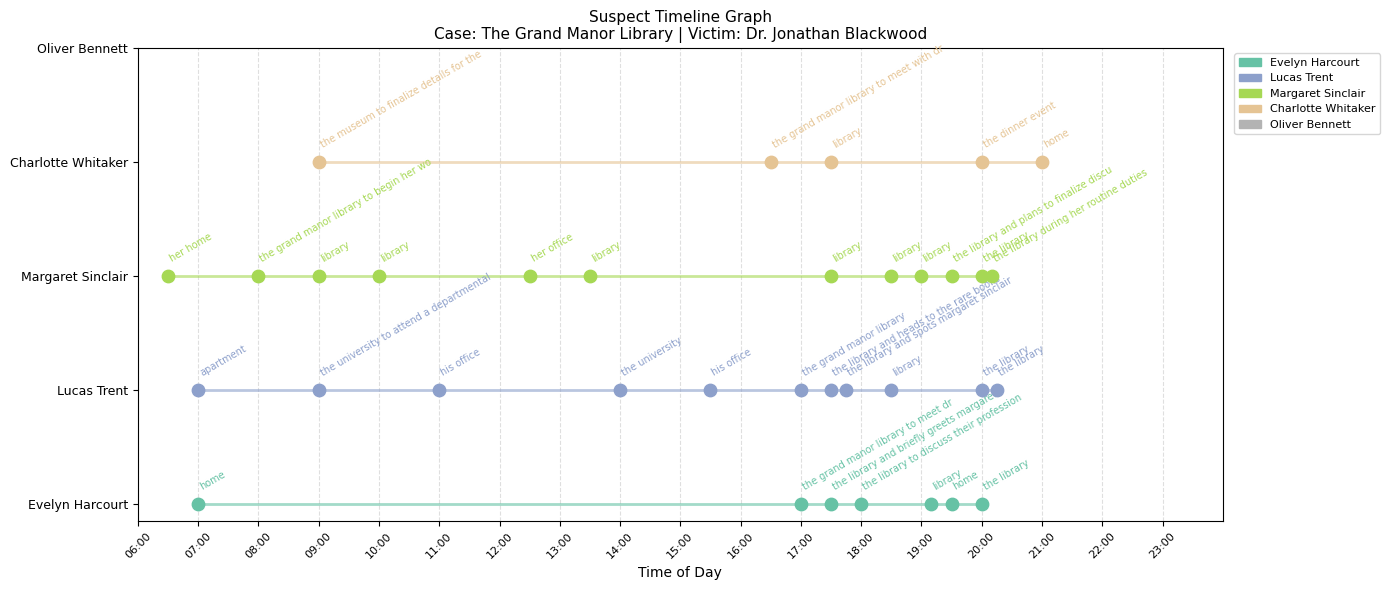

saved to timeline_graph.png


In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_timeline_graph(case: dict, graph: TimelineGraph):
    suspects = [s["name"] for s in case["suspects"]]
    colors   = plt.cm.Set2(np.linspace(0, 1, len(suspects)))
    color_map = {name: colors[i] for i, name in enumerate(suspects)}

    fig, ax = plt.subplots(figsize=(14, 6))

    for idx, name in enumerate(suspects):
        nodes = [n for n in graph.nodes if n.suspect == name]
        if not nodes:
            continue
        nodes = sorted(nodes, key=lambda n: n.time_mins)

        times  = [n.time_mins for n in nodes]
        locs   = [n.location  for n in nodes]
        y_vals = [idx] * len(nodes)

        ax.plot(times, y_vals,
                color=color_map[name], linewidth=2, alpha=0.6)

        for t, loc, y in zip(times, locs, y_vals):
            ax.scatter(t, y, color=color_map[name], s=80, zorder=5)
            ax.annotate(
                loc, (t, y),
                textcoords="offset points",
                xytext=(0, 10),
                fontsize=7,
                rotation=30,
                color=color_map[name],
            )

    ax.set_yticks(range(len(suspects)))
    ax.set_yticklabels(suspects, fontsize=9)

    time_ticks = list(range(0, 24*60, 60))
    ax.set_xticks(time_ticks)
    ax.set_xticklabels(
        [f"{h:02d}:00" for h in range(24)],
        fontsize=8, rotation=45
    )

    ax.set_xlabel("Time of Day")
    ax.set_title(
        f"Suspect Timeline Graph\n"
        f"Case: {case['location']} | Victim: {case['victim']['name']}",
        fontsize=11
    )
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.set_xlim(360, 1440)

    patches = [
        mpatches.Patch(color=color_map[n], label=n)
        for n in suspects
    ]
    ax.legend(handles=patches, loc="upper right",
              fontsize=8, bbox_to_anchor=(1.15, 1))

    plt.tight_layout()
    plt.savefig("timeline_graph.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("saved to timeline_graph.png")


case  = dataset[0]
inv   = Investigation(case)

for s in case["suspects"]:
    inv.graph.load_suspect(s["name"], s)

plot_timeline_graph(case, inv.graph)

In [22]:
token_log   = {"prompt": 0, "completion": 0, "total": 0}
eval_start  = time.time()
EVAL        = dataset[300:350]
results     = []

done = set()
for fn in os.listdir("outputs"):
    if fn.startswith("case_") and fn.endswith(".json"):
        try:
            done.add(int(fn.split("_")[1].split(".")[0]))
        except:
            pass

for i, case in enumerate(EVAL):
    cid = 300 + i
    if cid in done:
        print(f"skipping {cid}")
        continue

    print(f"\n{'=' * 55}")
    print(f"case {i+1}/{len(EVAL)}: {case['location']}")
    print(f"{'=' * 55}")

    t0 = time.time()

    try:
        result  = run_case(case)

        actual  = next(
            (s["name"] for s in case["suspects"]
             if s.get("is_murderer") is True),
            "Unknown",
        )
        our     = result.get("suspect") or "inconclusive"
        correct = our == actual
        elapsed = time.time() - t0

        row = {
            "case"     : case["location"],
            "our"      : our,
            "actual"   : actual,
            "correct"  : correct,
            "conf"     : result.get("conf"),
            "score"    : result.get("score", 0),
            "n_claims" : len(result.get("claims",  [])),
            "n_clashes": len(result.get("clashes", [])),
            "secs"     : round(elapsed, 1),
        }
        results.append(row)

        with open(f"outputs/case_{cid}.json", "w") as f:
            json.dump(row, f, indent=2)

        Report(case, result).save(f"{REPORTS_DIR}/case_{cid}.txt")

        print(f"\nour    : {our}")
        print(f"actual : {actual}")
        print(f"result : {'CORRECT' if correct else 'WRONG'}")
        print(f"time   : {elapsed:.1f}s")

    except Exception as e:
        print(f"[error] case {i+1}: {e}")
        with open(f"logs/err_{cid}.json", "w") as f:
            json.dump({"cid": cid, "err": str(e)}, f)
        results.append({
            "case": case.get("location", "?"), "our": "error",
            "actual": "?", "correct": False, "conf": None,
            "score": 0, "n_claims": 0, "n_clashes": 0, "secs": 0,
        })
    finally:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print(f"\ndone in {(time.time()-eval_start)/60:.1f} mins.")

Streaming output truncated to the last 5000 lines.
[why]   need baseline alibi and relationship info from everyone first.
[SuspectAgent] Margaret Sinclair error: Error code: 429 - [{'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 26.727004323s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_re

In [23]:
import os, json

results = []
for fname in os.listdir("outputs"):
    if fname.startswith("case_") and fname.endswith(".json"):
        try:
            with open(f"outputs/{fname}") as f:
                results.append(json.load(f))
        except:
            pass

print(f"loaded {len(results)} completed cases from outputs/")

correct = sum(1 for r in results if r.get("correct", False))
total   = len(results)
acc     = correct / total * 100 if total else 0

avg_claims  = sum(r.get("n_claims",  0) for r in results) / total if total else 0
avg_clashes = sum(r.get("n_clashes", 0) for r in results) / total if total else 0
avg_time    = sum(r.get("secs",      0) for r in results) / total if total else 0

print(f"\naccuracy  : {acc:.1f}%  ({correct}/{total})")
print(f"avg claims: {avg_claims:.1f}")
print(f"avg clashes: {avg_clashes:.1f}")
print(f"avg time  : {avg_time:.1f}s")

print("\nbreakdown:")
for r in results:
    tag = "OK" if r.get("correct") else "XX"
    print(
        f"  [{tag}] {r.get('case','?')[:35]:<35} "
        f"our={r.get('our','?')[:18]:<18} "
        f"actual={r.get('actual','?')}"
    )

loaded 50 completed cases from outputs/

accuracy  : 70.0%  (35/50)
avg claims: 1.4
avg clashes: 0.0
avg time  : 45.7s

breakdown:
  [OK] The Grand Manor Library             our=Professor Jonathan actual=Professor Jonathan Blackwood
  [OK] Old Manor Library                   our=Dr. Evelyn Hart    actual=Dr. Evelyn Hart
  [OK] Old Manor Library                   our=Dr. Evelyn Carter  actual=Dr. Evelyn Carter
  [XX] The Grand Library                   our=Isabella Greene    actual=Professor Marcus Lang
  [XX] Victorian Manor Library             our=Lady Margaret Whit actual=Professor Eleanor Graves
  [OK] Riverside Manor, a secluded estate  our=Evelyn Sinclair    actual=Evelyn Sinclair
  [OK] Riverside Manor                     our=Evelyn Hart        actual=Evelyn Hart
  [OK] Old Manor Library                   our=Eleanor Harper     actual=Eleanor Harper
  [OK] Riverside Manor Library             our=Professor Charles  actual=Professor Charles Adler
  [OK] The Old Manor Library       

In [24]:
import os
os.makedirs("outputs", exist_ok=True)
os.makedirs("logs",    exist_ok=True)
os.makedirs("reports", exist_ok=True)
print("folders created.")

folders created.


In [25]:
import os, json

results = []
for fname in os.listdir("outputs"):
    if fname.startswith("case_") and fname.endswith(".json"):
        try:
            with open(f"outputs/{fname}") as f:
                results.append(json.load(f))
        except:
            pass

print(f"loaded {len(results)} completed cases from outputs/")

correct = sum(1 for r in results if r.get("correct", False))
total   = len(results)
acc     = correct / total * 100 if total else 0

avg_claims  = sum(r.get("n_claims",  0) for r in results) / total if total else 0
avg_clashes = sum(r.get("n_clashes", 0) for r in results) / total if total else 0
avg_time    = sum(r.get("secs",      0) for r in results) / total if total else 0

print(f"\naccuracy  : {acc:.1f}%  ({correct}/{total})")
print(f"avg claims: {avg_claims:.1f}")
print(f"avg clashes: {avg_clashes:.1f}")
print(f"avg time  : {avg_time:.1f}s")

print("\nbreakdown:")
for r in results:
    tag = "OK" if r.get("correct") else "XX"
    print(
        f"  [{tag}] {r.get('case','?')[:35]:<35} "
        f"our={r.get('our','?')[:18]:<18} "
        f"actual={r.get('actual','?')}"
    )

loaded 50 completed cases from outputs/

accuracy  : 70.0%  (35/50)
avg claims: 1.4
avg clashes: 0.0
avg time  : 45.7s

breakdown:
  [OK] The Grand Manor Library             our=Professor Jonathan actual=Professor Jonathan Blackwood
  [OK] Old Manor Library                   our=Dr. Evelyn Hart    actual=Dr. Evelyn Hart
  [OK] Old Manor Library                   our=Dr. Evelyn Carter  actual=Dr. Evelyn Carter
  [XX] The Grand Library                   our=Isabella Greene    actual=Professor Marcus Lang
  [XX] Victorian Manor Library             our=Lady Margaret Whit actual=Professor Eleanor Graves
  [OK] Riverside Manor, a secluded estate  our=Evelyn Sinclair    actual=Evelyn Sinclair
  [OK] Riverside Manor                     our=Evelyn Hart        actual=Evelyn Hart
  [OK] Old Manor Library                   our=Eleanor Harper     actual=Eleanor Harper
  [OK] Riverside Manor Library             our=Professor Charles  actual=Professor Charles Adler
  [OK] The Old Manor Library       

In [26]:
import os, json

results = []
for fname in os.listdir("outputs"):
    if fname.startswith("case_") and fname.endswith(".json"):
        try:
            with open(f"outputs/{fname}") as f:
                results.append(json.load(f))
        except:
            pass

print(f"loaded {len(results)} completed cases from outputs/")

if not results:
    print("no results yet — run Cell 12 first.")
else:
    correct = sum(1 for r in results if r.get("correct", False))
    total   = len(results)
    acc     = correct / total * 100 if total else 0

    avg_claims  = sum(r.get("n_claims",  0) for r in results) / total
    avg_clashes = sum(r.get("n_clashes", 0) for r in results) / total
    avg_time    = sum(r.get("secs",      0) for r in results) / total

    print(f"\naccuracy   : {acc:.1f}%  ({correct}/{total})")
    print(f"avg claims : {avg_claims:.1f}")
    print(f"avg clashes: {avg_clashes:.1f}")
    print(f"avg time   : {avg_time:.1f}s")
    print(f"\ntokens used:")
    print(f"  prompt     : {token_log['prompt']:,}")
    print(f"  completion : {token_log['completion']:,}")
    print(f"  total      : {token_log['total']:,}")

    print("\nbreakdown:")
    for r in results:
        tag = "OK" if r.get("correct") else "XX"
        print(
            f"  [{tag}] {r.get('case','?')[:35]:<35} "
            f"our={r.get('our','?')[:18]:<18} "
            f"actual={r.get('actual','?')}"
        )

    summary = {
        "total"     : total,
        "correct"   : correct,
        "accuracy"  : round(acc, 2),
        "avg_claims": round(avg_claims, 2),
        "avg_clashes": round(avg_clashes, 2),
        "avg_time"  : round(avg_time, 2),
        "tokens"    : token_log,
        "cases"     : results,
    }
    with open("summary.json", "w") as f:
        json.dump(summary, f, indent=2)
    print("\nsaved to summary.json")

loaded 50 completed cases from outputs/

accuracy   : 70.0%  (35/50)
avg claims : 1.4
avg clashes: 0.0
avg time   : 45.7s

tokens used:
  prompt     : 1,412
  completion : 2,018
  total      : 3,430

breakdown:
  [OK] The Grand Manor Library             our=Professor Jonathan actual=Professor Jonathan Blackwood
  [OK] Old Manor Library                   our=Dr. Evelyn Hart    actual=Dr. Evelyn Hart
  [OK] Old Manor Library                   our=Dr. Evelyn Carter  actual=Dr. Evelyn Carter
  [XX] The Grand Library                   our=Isabella Greene    actual=Professor Marcus Lang
  [XX] Victorian Manor Library             our=Lady Margaret Whit actual=Professor Eleanor Graves
  [OK] Riverside Manor, a secluded estate  our=Evelyn Sinclair    actual=Evelyn Sinclair
  [OK] Riverside Manor                     our=Evelyn Hart        actual=Evelyn Hart
  [OK] Old Manor Library                   our=Eleanor Harper     actual=Eleanor Harper
  [OK] Riverside Manor Library             our=Profe